# ML4NLP1
## Starting Point for Exercise 1, part II

This notebook is supposed to serve as a starting point and/or inspiration when starting exercise 1, part II.

One of the goals of this exercise is o make you acquainted with **skorch**. You will probably need to consult the [documentation](https://skorch.readthedocs.io/en/stable/).

---

### Declaration of Usage of Generative AI
In this work, Generative AI was used to refine the wording of **some** written paragraphs and comments, including the ones in the final report, to improve their clarity and style, as English is not the native language of any of the group members. The underlying ideas and content remain entirely our own. In terms of coding, AI assistance was limited **only** to the cell for setting up with the grid search to understand how to link `max_features` and `input_size` hyperparameters in the parameter grid. **No** generative AI tools were used as a learning assistant during the completion of this exercise.

---

# Installing skorch and loading libraries

In [ ]:
import subprocess

# Installation on Google Colab
try:
    import google.colab
    subprocess.run(['python', '-m', 'pip', 'install', 'skorch'])
except ImportError:
    pass

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier

import pandas as pd
import numpy as np
import csv
import re
import string
from collections import defaultdict

# Set seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

## Training a classifier and making predictions

In [ ]:
# Download dataset
!gdown 1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs # x_train
!gdown 1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6 # x_test
!gdown 1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl # y_train
!gdown 1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X # y_test

Downloading...
From: https://drive.google.com/uc?id=1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs
To: /content/x_train.txt
100% 64.1M/64.1M [00:00<00:00, 203MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6
To: /content/x_test.txt
100% 65.2M/65.2M [00:00<00:00, 158MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl
To: /content/y_train.txt
100% 480k/480k [00:00<00:00, 128MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X
To: /content/y_test.txt
100% 480k/480k [00:00<00:00, 90.6MB/s]


In [ ]:
with open(f'x_train.txt') as f:
    x_train = f.read().splitlines()
with open(f'y_train.txt') as f:
    y_train = f.read().splitlines()
with open(f'x_test.txt') as f:
    x_test = f.read().splitlines()
with open(f'y_test.txt') as f:
    y_test = f.read().splitlines()

In [ ]:
# Combine x_train and y_train into one dataframe
train_df = pd.DataFrame({'text': x_train, 'label': y_train})

# Write train_df to csv with tab as separator
train_df.to_csv('train_df.csv', index=False, sep='\t')

# Comibne x_test and y_test into one dataframe
test_df = pd.DataFrame({'text': x_test, 'label': y_test})

# Inspect the first 5 items in the train split
train_df.head()


,text,label
0,Klement Gottwaldi surnukeha palsameeriti ning ...,est
1,"Sebes, Joseph; Pereira Thomas (1961) (på eng)....",swe
2,भारतीय स्वातन्त्र्य आन्दोलन राष्ट्रीय एवम क्षे...,mai
3,"Après lo cort periòde d'establiment a Basilèa,...",oci
4,ถนนเจริญกรุง (อักษรโรมัน: Thanon Charoen Krung...,tha


### Data preparation

Prepare your dataset for this experiment using the same method as you did in part 1.

Get a subset of the train/test data that includes 20 languages. Include English, German, Dutch, Danish, Swedish, Norwegian, and Japanese, plus 13 additional languages of your choice based on the items in the list of labels.

Don't forget to encode your labels using the adjusted code snippet from part 1!


In [ ]:
# Create the train/test subsets of languages, the code is the same as in Part 1
from sklearn.model_selection import train_test_split

# Concatenate train and test set
df = pd.concat([train_df, test_df])

# Create a new 80/20 stratified split
train_df, test_df = train_test_split(df,
                                     test_size=0.2,
                                     random_state=42,
                                     stratify=df['label'])

# Define the languages of interest
labels = ['eng', 'deu', 'nld', 'dan', 'swe', 'nob', 'jpn', 'est', 'kir', 'lat',
          'tat', 'ukr', 'tha', 'spa', 'isl', 'aze', 'hrv', 'hun', 'pol', 'ita']

# Create our train/test subsets of languages
train_df_sub = train_df[train_df['label'].isin(labels)].copy()
test_df_sub = test_df[test_df['label'].isin(labels)].copy()

# Number of instances per label in training and test sets
pd.DataFrame({
    'train': train_df_sub['label'].value_counts().sort_index(),
    'test':  test_df_sub['label'].value_counts().sort_index()
})


,train,test
label,,
aze,800,200
dan,800,200
deu,800,200
eng,800,200
est,800,200
hrv,800,200
hun,800,200
isl,800,200
ita,800,200


In [ ]:
# Encode the labels and check that the splits used are the same as in Part 1
from sklearn.preprocessing import LabelEncoder

# Fit encoder on training labels
label_encoder = LabelEncoder().fit(train_df_sub['label'])

# Transform train and test labels
train_df_sub['target'] = label_encoder.transform(train_df_sub['label'])
test_df_sub['target'] = label_encoder.transform(test_df_sub['label'])

# Report the results
print("The labels for each class:", label_encoder.classes_)
print("Encoded training labels:", train_df_sub['target'].to_numpy())
print("Encoded test labels:", test_df_sub['target'].to_numpy())

The labels for each class: ['aze' 'dan' 'deu' 'eng' 'est' 'hrv' 'hun' 'isl' 'ita' 'jpn' 'kir' 'lat'
 'nld' 'nob' 'pol' 'spa' 'swe' 'tat' 'tha' 'ukr']
Encoded training labels: [ 9 15  6 ... 19  7  9]
Encoded test labels: [ 0 13 13 ... 19  0 13]


In [ ]:
# Assign the extracted subset of features and targets to the corresponding variables
x_train = train_df_sub['text'].to_numpy()
y_train = train_df_sub['target'].to_numpy()
x_test = test_df_sub['text'].to_numpy()
y_test = test_df_sub['target'].to_numpy()

### Feature Extraction

In [ ]:
# First, we extract some simple features as input for the neural network
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 2), max_features=100, binary=True)
X = vectorizer.fit_transform(x_train)

In [ ]:
# We need to change the datatype to make it play nice with pytorch
X = X.astype(np.float32)
y = y_train.astype(np.int64)

In the following, we define a vanilla neural network with two hidden layers. The output layer should have as many outputs as there are classes. In addition, it should have a nonlinearity function.

In [ ]:
# The input size must correspond to the dimensionality of the vectorizer output,
# i.e. the vocabulary size or max_features value (eqals 100 in our case), whereas
# the output size must correspond to the number of classes (equals 20 in our case),
# i.e. the number of languages
class ClassifierModule(nn.Module):
    def __init__(
        self,
        input_size=100,        # Made input size as a hyperparameter (was hardcoded before)
        hidden_dim1=200,
        hidden_dim2=50,        # Added configurable size of the 2nd hidden layer for GridSearchCV
        nonlin=F.relu,
        num_classes=20,        # Added hyperparameter for the number of output classes.
    ):
        super(ClassifierModule, self).__init__()
        self.hidden_dim1 = hidden_dim1
        self.hidden_dim2 = hidden_dim2
        self.nonlin = nonlin

        self.dense0 = nn.Linear(input_size, hidden_dim1)   # Output of dense0 and input of dense1
        self.nonlin = nonlin                               # is of dimension hidden_dim1
        self.dense1 = nn.Linear(hidden_dim1, hidden_dim2)  # Output of dense1 and input of the output
        self.output = nn.Linear(hidden_dim2, num_classes)  # layer is of dimension hidden_dim2

    def forward(self, X, **kwargs):
        X = self.nonlin(self.dense0(X))
        X = F.relu(self.dense1(X))
        X = self.output(X)
        return X.squeeze(dim=1)

In [ ]:
# Initalise the neural net classifier
net = NeuralNetClassifier(
    ClassifierModule(
        input_size=X.shape[1],
        hidden_dim1=200,
        hidden_dim2=50,
        nonlin=F.relu,
        num_classes=len(label_encoder.classes_)
    ),
    max_epochs=20,
    criterion=nn.CrossEntropyLoss(),
    lr=0.1,
    device='cuda',  # comment this to train with CPU
)

In [ ]:
# Train the classifier
net.fit(X, y)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        2.7740       0.2919        2.4527  1.1258
      2        1.8623       0.5384        1.3777  1.0000
      3        1.1518       0.6294        1.0551  1.0054
      4        0.9030       0.6806        0.8920  1.0089
      5        0.7808       0.7066        0.7937  1.0294
      6        0.7058       0.7216        0.7406  1.0107
      7        0.6594       0.7250        0.7065  1.0171
      8        0.6281       0.7319        0.6836  1.0167
      9        0.6050       0.7378        0.6664  1.0193
     10        0.5869       0.7384        0.6538  1.1658
     11        0.5720       0.7406        0.6447  1.4594
     12        0.5594       0.7450        0.6369  1.2170
     13        0.5482       0.7478        0.6312  1.0126
     14        0.5382       0.7494        0.6266  1.0391
     15        0.5292       0.7519        0.6218  1.0165
     16        0.5210       0.7

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=ClassifierModule(
    (dense0): Linear(in_features=100, out_features=200, bias=True)
    (dense1): Linear(in_features=200, out_features=50, bias=True)
    (output): Linear(in_features=50, out_features=20, bias=True)
  ),
)

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

# Use the trained classifier to make predictions on the test set
X_test = vectorizer.transform(x_test)
X_test = X_test.astype(np.float32)
y_pred = net.predict(X_test)

# Evaluate model performance using accuracy, precision, recall, and F1 score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro')}")
print(f"Recall: {recall_score(y_test, y_pred, average='macro')}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='macro')}")

Accuracy: 0.773
Precision: 0.7761128043370802
Recall: 0.7729999999999999
F1 Score: 0.7701175784623484


Note, you can also use `GridSearchCV` with `skorch`, but be aware that training a neural network takes much more time.

Play around with 5 different sets of hyperparameters. For example, consider some of the following:

- layer sizes
- activation functions
- regularizers
- early stopping
- vectorizer parameters


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Convert y arrays to int64
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test, dtype=np.int64)

# FunctionTransformer converts the vectorizer output into float32, since
# PyTorch requires float32 input, CountVectorizer outputs int64 by default
to_float = FunctionTransformer(lambda x: x.astype(np.float32))

# Create a pipeline that transforms raw text into model predictions
pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('to_float', to_float),
    ('classifier', NeuralNetClassifier(
                          ClassifierModule(input_size=X.shape[1],
                                           hidden_dim1=200,
                                           hidden_dim2=50,
                                           nonlin=F.relu,
                                           num_classes=len(label_encoder.classes_)),
                                      max_epochs=20,
                                      criterion=nn.CrossEntropyLoss(),
                                      lr=0.1,
                                      device='cuda',  # comment this to train with CPU
                                    ))
     ])

In [ ]:
# We decided to tune the following hyperparameters:
#   • hidden_dim1, i.e. the number of neurons in the first hidden layer
#   • hidden_dim2, i.e. the number of neurons in the second hidden layer
#   • activation function
#   • weight_decay, i.e. the L2 regularization strength
#   • max_features in the vectorizer, which also requires updating the model's
#     input_size accordingly
from skorch.callbacks import EarlyStopping
from sklearn.model_selection import GridSearchCV

# Define the shared parameter grid, i.e. parameters that can be tuned independently,
# unlike max_features and input_size, which must be set together
shared = {
    'classifier__module__hidden_dim1': [200, 400],
    'classifier__module__hidden_dim2': [50, 100],
    'classifier__module__nonlin': [F.sigmoid, F.relu],
    'classifier__optimizer__weight_decay': [0.0, 0.01],

    # Apply early stopping with a patience of 5 for all configurations
    # to reduce the overall grid search time
    'classifier__callbacks': [[('EarlyStopping', EarlyStopping(patience=5))]],
}

# Define the feature space sizes to explore
sizes = [100, 500]

# Create one parameter dictionary per size to link max_features with input_size
param_grid = [
    {
        **shared,
        'vectorizer__max_features': [s],
        'classifier__module__input_size': [s],
    }
    for s in sizes
]

In [ ]:
# Grid search with 3-fold cross-validation optimizing accuracy
gs_pipeline = GridSearchCV(pipeline,
                           param_grid,
                           scoring='accuracy',
                           cv=3,
                           refit=True,  # Refit the best combination on the full training set
                           verbose=1)
gs_pipeline.fit(x_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        2.9823       0.0975        2.9559  0.7328
      2        2.8805       0.1026        2.7451  0.6678
      3        2.5909       0.1064        2.4966  0.6813
      4        2.4514       0.1200        2.4304  0.6921
      5        2.3959       0.1354        2.3798  0.6874
      6        2.3407       0.1584        2.3167  0.6887
      7        2.2642       0.1987        2.2237  0.6833
      8        2.1454       0.2732        2.0811  0.6710
      9        1.9789       0.3346        1.9037  0.6941
     10        1.8005       0.3716        1.7413  0.6912
     11        1.6419       0.4100        1.6071  0.6730
     12        1.5046       0.4569        1.4915  0.7027
     13        1.3836       0.4944        1.3895  0.8083
     14        1.2776       0.5141        1.3022  0.9687
     15        1.1870      

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('vectorizer',
                                        CountVectorizer(analyzer='char',
                                                        binary=True,
                                                        max_features=100,
                                                        ngram_range=(2, 2))),
                                       ('to_float',
                                        FunctionTransformer(func=<function <lambda> at 0x7f7536aba3e0>)),
                                       ('classifier',
                                        NeuralNetClassifier(_params_to_validate=set(), batch_size=128, callbacks=None, compile=False, criterion=CrossEntropyLoss(), data...
                                                      <skorch.callbacks.training.EarlyStopping object at 0x7f7536987740>)]],
                          'classifier__module__hidden_dim1': [200, 400],
                          'classifier__module__hidden_dim2': [50, 100],
                          'classifier__module__input_size': [500],
                          'classifier__module__nonlin': [<function sigmoid at 0x7f756818b380>,
                                                         <function relu at 0x7f756818a8e0>],
                          'classifier__optimizer__weight_decay': [0.0, 0.01],
                          'vectorizer__max_features': [500]}],
             scoring='accuracy', verbose=1)

☝ Note, during model development, if you run into the infamous CUDA out-of-memory (OOM) error, try clearing the GPU memory either with `torch.cuda.empty_cache()` or restarting the runtime.


Report your best hyperparameter combination.

📝❓ What is the effect of your modifcations on validation performance? Discuss potential reasons.


In [ ]:
# Inspect the results of the Grid Search
gs_df = pd.DataFrame.from_dict(gs_pipeline.cv_results_)
gs_df.sort_values(by=['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__callbacks,param_classifier__module__hidden_dim1,param_classifier__module__hidden_dim2,param_classifier__module__input_size,param_classifier__module__nonlin,param_classifier__optimizer__weight_decay,param_vectorizer__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
26,16.932856,0.271960,1.330753,0.149861,"[(EarlyStopping, <skorch.callbacks.training.Ea...",400,50,500,<function relu at 0x7f756818a8e0>,0.00,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.943570,0.956122,0.950497,0.950063,0.005134,1
22,17.135382,0.370807,1.252943,0.004952,"[(EarlyStopping, <skorch.callbacks.training.Ea...",200,100,500,<function relu at 0x7f756818a8e0>,0.00,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.943382,0.954060,0.944872,0.947438,0.004722,2
30,17.094002,0.292499,1.313330,0.115966,"[(EarlyStopping, <skorch.callbacks.training.Ea...",400,100,500,<function relu at 0x7f756818a8e0>,0.00,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.947319,0.955747,0.938684,0.947250,0.006966,3
18,17.045966,0.414605,1.232612,0.016101,"[(EarlyStopping, <skorch.callbacks.training.Ea...",200,50,500,<function relu at 0x7f756818a8e0>,0.00,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.940757,0.951997,0.942059,0.944938,0.005020,4
31,17.150316,0.215733,1.536354,0.209583,"[(EarlyStopping, <skorch.callbacks.training.Ea...",400,100,500,<function relu at 0x7f756818a8e0>,0.01,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.937008,0.944684,0.897244,0.926312,0.020792,5
27,17.200612,0.275090,1.473844,0.151969,"[(EarlyStopping, <skorch.callbacks.training.Ea...",400,50,500,<function relu at 0x7f756818a8e0>,0.01,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.932321,0.942434,0.881680,0.918812,0.026579,6
19,17.401320,0.407727,1.243715,0.003737,"[(EarlyStopping, <skorch.callbacks.training.Ea...",200,50,500,<function relu at 0x7f756818a8e0>,0.01,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.928571,0.938871,0.885055,0.917499,0.023324,7
23,17.347492,0.446358,1.254594,0.029150,"[(EarlyStopping, <skorch.callbacks.training.Ea...",200,100,500,<function relu at 0x7f756818a8e0>,0.01,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.930446,0.940371,0.879055,0.916624,0.026873,8
20,17.146464,0.405238,1.242765,0.004420,"[(EarlyStopping, <skorch.callbacks.training.Ea...",200,100,500,<function sigmoid at 0x7f756818b380>,0.00,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.900262,0.912807,0.825614,0.879561,0.038489,9
16,17.114665,0.287672,1.223044,0.005787,"[(EarlyStopping, <skorch.callbacks.training.Ea...",200,50,500,<function sigmoid at 0x7f756818b380>,0.00,500,"{'classifier__callbacks': [('EarlyStopping', <...",0.895201,0.905307,0.821864,0.874124,0.037183,10


In [ ]:
print(f"Best hyperparameter combination: {gs_pipeline.best_params_} "
      f"with a cross-validation score of {gs_pipeline.best_score_}")

Best hyperparameter combination: {'classifier__callbacks': [('EarlyStopping', <skorch.callbacks.training.EarlyStopping object at 0x7f7536987740>)], 'classifier__module__hidden_dim1': 400, 'classifier__module__hidden_dim2': 50, 'classifier__module__input_size': 500, 'classifier__module__nonlin': <function relu at 0x7f756818a8e0>, 'classifier__optimizer__weight_decay': 0.0, 'vectorizer__max_features': 500} with a cross-validation score of 0.9500629058345017


In [ ]:
from sklearn.metrics import classification_report

# The pipeline with the best configuration retrained on all training data is already
# stored in gs.best_estimator_. Let us generate predictions on the held-out test set
y_pred = gs_pipeline.best_estimator_.predict(x_test)

# Evaluate model performance using accuracy, precision, recall, and F1 score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro')}")
print(f"Recall: {recall_score(y_test, y_pred, average='macro')}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='macro')}")

# Print a detailed report per class
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred,
                            target_names=label_encoder.classes_, digits=3))


Accuracy: 0.945
Precision: 0.9474223121709686
Recall: 0.945
F1 Score: 0.9449436789049919

Classification Report:

              precision    recall  f1-score   support

         aze      0.990     0.980     0.985       200
         dan      0.843     0.940     0.889       200
         deu      0.964     0.950     0.957       200
         eng      0.940     0.940     0.940       200
         est      0.989     0.930     0.959       200
         hrv      1.000     0.980     0.990       200
         hun      0.995     0.975     0.985       200
         isl      1.000     0.975     0.987       200
         ita      0.915     0.975     0.944       200
         jpn      0.783     0.920     0.846       200
         kir      0.959     0.940     0.949       200
         lat      0.889     0.965     0.926       200
         nld      0.975     0.980     0.978       200
         nob      0.943     0.825     0.880       200
         pol      0.980     0.995     0.988       200
         spa      0.9

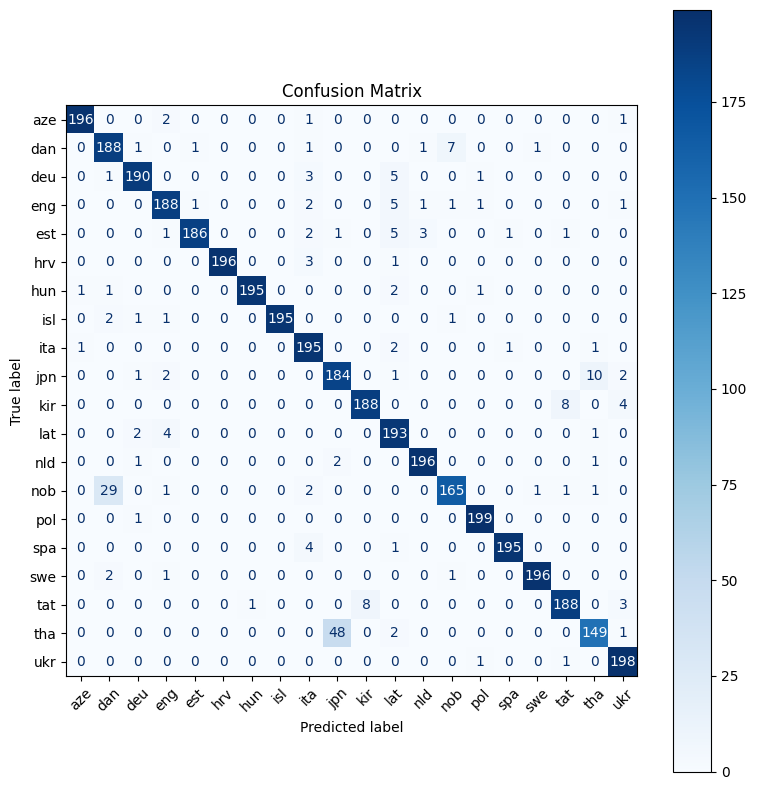

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix for the model's predictions
cm = confusion_matrix(test_df_sub['target'], y_pred)

# Display the confusion matrix as a heatmap
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Best hyperparameter combination:
*   Size of the 1st hidden layer (`hidden_dim1`): 400
*   Size of the 2nd hidden layer  (`hidden_dim2`): 50
*   Number of features  (`max_features`): 500
*   Activation function: ReLU
*   $L^2$ regularization strength (`weight_decay`): 0.0




---

📝❓ Write your lab report here addressing all questions in the notebook

### Final Report

In this work, we performed a language classification task using the `skorch` library. Specifically, we:
1. **Built** a simple neural network classifier using Pytorch.
2. **Trained** our neural network classifier with Skorch on a GPU using Google Colab.
3. **Improved** the model's accuracy above 87%.


 ✅ Our best model achieved **94.5% accuracy** on the test set, surpassing the task benchmark of 87%. The following hyperparameter modifications had an impact on performance:

* **Hidden layer dimensions:**
  Having more units in each layer does not necessarily lead to higher accuracy. The model with the maximum number of units in the first hidden layer and the smallest size in the second hidden layer achieved the highest accuracy overall. In contrast, the configuration with the maximum total number of parameters achieved only the third-best result in cross-validation.

* **Vectorizer features:**
  Increasing the number of features in the vectorizer consistently improved predictions. The top 15 models used `max_features = 500`, which makes sense: a higher feature count allows the classifier to capture more information for distinguishing between classes, while still controlling noise by capping dimensionality.

* **Activation function:**
  Models using the ReLU activation function outperformed those using Sigmoid. This trend is seen in the dataframe with the grid search results, where the top 8 models all used ReLU.

* **Regularization:**
  The top 4 models all had a weight decay of `0.0`, thus, introducing regularization hindered rather than helped performance in our case.

Interestingly, the top 4 models differed only in the size of their hidden layers, while sharing the same three hyperparameter settings: ReLU activation, no weight decay, and `max_features = 500`. Their performance varied by only about **1.5%**, suggesting that while model size contributed, the main performance gains came from these key hyperparameters rather than from network depth or width alone.

---

#### Potential reasons behind these observations:

* Increasing the model size does not necessarily improve results because larger networks are more prone to overfitting.

* ReLU avoids vanishing gradient problems common with Sigmoid. This likely allowed the model to converge to a better solution.

* Increasing the number of features provided richer input representations, improving separability between classes. However, limiting it to 500 features prevented overfitting and excessive noise.

* The model may have been underfitting initially, so regularization reduced its capacity unnecessarily. The data might also have been relatively clean, reducing the need for penalization.
